# Task 1 — Exploratory Data Analysis & Preprocessing

**Intelligent Complaint Analysis for Financial Services (CrediTrust)**

This notebook explores the CFPB consumer-complaint dataset and prepares a cleaned,
filtered corpus for the RAG pipeline.

The raw export is ~6 GB uncompressed (9.6M rows), so the **full** pass is executed
by the streaming script [`src/eda_preprocessing.py`](../src/eda_preprocessing.py),
which writes:
- `data/filtered_complaints.csv` — cleaned + filtered corpus
- `reports/eda_summary.json` — machine-readable stats
- `reports/figures/*.png` — the charts shown below

Run it once with:
```bash
python src/eda_preprocessing.py --zip "C:/Users/coop/Downloads/complaints.csv.zip"
```
This notebook then loads those artifacts and demonstrates the EDA logic on a sample.

In [1]:
import json, sys, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / 'src'))
from eda_preprocessing import PRODUCT_MAP, clean_narrative  # reuse project logic

ZIP = Path('C:/Users/coop/Downloads/complaints.csv.zip')
FIG = ROOT / 'reports' / 'figures'
print('Project root:', ROOT)

Project root: c:\Users\coop\rag-complaint-chatbot


## 1. A first look at the raw data
We read a modest sample (first 200k rows) for interactive inspection — enough to
see the schema and distributions without loading the whole 6 GB file.

In [2]:
with zipfile.ZipFile(ZIP) as zf:
    name = zf.namelist()[0]
    with zf.open(name) as fh:
        sample = pd.read_csv(fh, dtype=str, nrows=200_000)
print('shape:', sample.shape)
sample.head(3)

shape: (200000, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


In [ ]:
sample.columns.tolist()

## 2. Full-dataset statistics
These numbers come from the complete streaming pass (`reports/eda_summary.json`).

In [3]:
summary = json.loads((ROOT / 'reports' / 'eda_summary.json').read_text())
print(f"Total rows............ {summary['total_rows']:,}")
print(f"With narrative........ {summary['rows_with_narrative']:,} ({summary['pct_with_narrative']}%)")
print(f"Without narrative..... {summary['rows_without_narrative']:,}")
print(f"Filtered rows written. {summary['filtered_rows_written']:,}")
print('\nComplaints per target category:')
for k, v in summary['category_counts'].items():
    print(f'  {k:<16} {v:,}')

Total rows............ 9,609,797
With narrative........ 2,980,756 (31.02%)
Without narrative..... 6,629,041
Filtered rows written. 480,576

Complaints per target category:
  Credit Card      189,334
  Savings Account  155,204
  Money Transfer   98,701
  Personal Loan    37,341


### 2.1 Product distribution (full dataset)
CFPB uses many overlapping product labels (current + legacy). Credit-reporting
complaints dominate the corpus; our four target families sit further down the list.

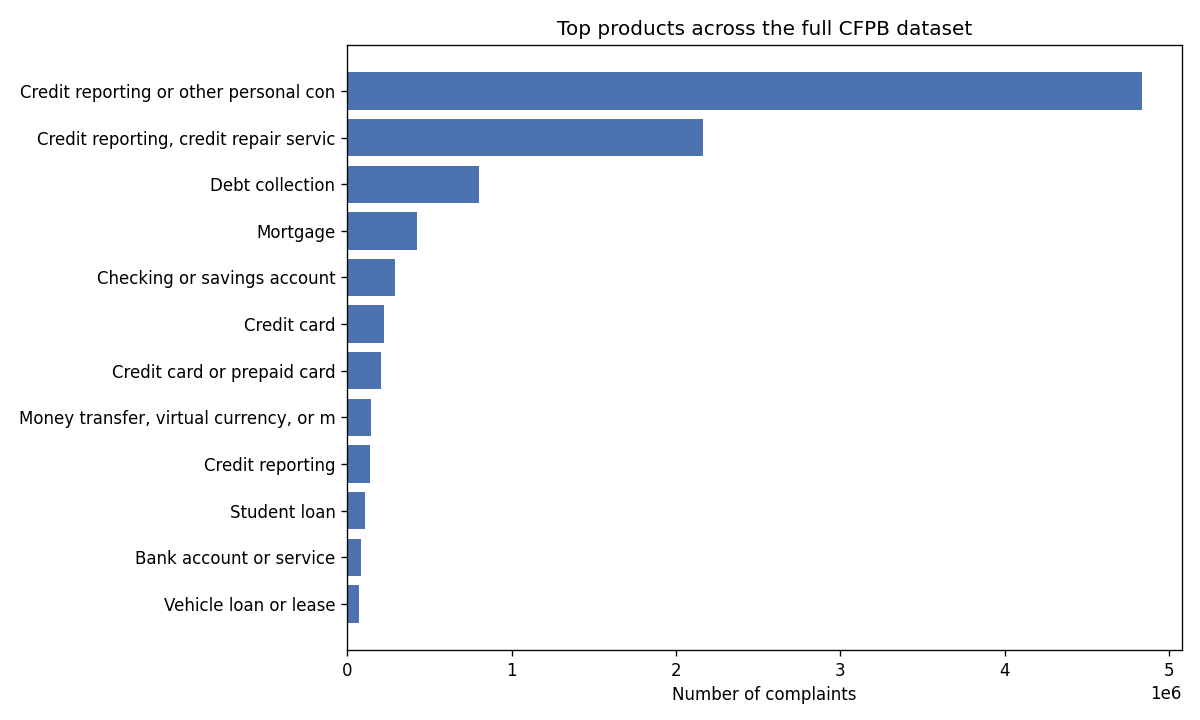

In [4]:
display(Image(str(FIG / 'product_distribution_full.png')))

### 2.2 Narrative availability
Only about a third of complaints include a free-text narrative — the rest are
metadata-only and unusable for semantic search, so they are dropped.

In [ ]:
display(Image(str(FIG / 'narrative_availability.png')))

### 2.3 Target-category counts (with narrative)

In [ ]:
display(Image(str(FIG / 'target_category_counts.png')))

### 2.4 Narrative length
Word-count distribution for the four target families. Most narratives are short–
medium; a long tail of very detailed complaints motivates the chunking strategy in Task 2.

In [ ]:
wc = summary['narrative_wordcount']
print(f"count  {wc['count']:,}")
print(f"min / median / max = {wc['min']} / {wc['median']} / {wc['max']:,}")
print(f"mean = {wc['mean']}")
print(f"percentiles [1,25,50,75,95,99] = {wc['p1_p25_p50_p75_p95_p99']}")
print(f"very short (<5 words):  {wc['very_short_lt5_words']:,}")
print(f"very long (>300 words): {wc['very_long_gt300_words']:,}")
display(Image(str(FIG / 'narrative_wordcount_hist.png')))

## 3. Filtering & the product mapping
The four target families are assembled from these raw CFPB `Product` labels:

In [ ]:
pd.DataFrame(sorted(PRODUCT_MAP.items()), columns=['CFPB Product', 'Target category'])

## 4. Text cleaning — before / after
`clean_narrative()` lowercases, removes CFPB `XXXX` redactions, strips boilerplate
openers ("I am writing to file a complaint..."), drops special characters, and
normalises whitespace.

In [ ]:
narr = sample.loc[sample['Consumer complaint narrative'].notna(), 'Consumer complaint narrative']
for raw in narr.head(3):
    print('RAW  :', raw[:220])
    print('CLEAN:', clean_narrative(raw)[:220])
    print('-' * 90)

## 5. Preview of the cleaned, filtered dataset
Saved to `data/filtered_complaints.csv` — the input for Task 2.

In [ ]:
filtered = pd.read_csv(ROOT / 'data' / 'filtered_complaints.csv', nrows=1000)
print('columns:', filtered.columns.tolist())
filtered[['product_category', 'Issue', 'Company', 'cleaned_narrative']].head(5)

## 6. Key EDA findings (summary)

1. **Scale & sparsity.** The full CFPB export holds ~9.6M complaints, but only ~31%
   carry a free-text consumer narrative. Since the RAG system relies on narratives
   for semantic retrieval, the ~6.6M narrative-less records are dropped.
2. **Product skew.** Credit-reporting complaints dominate the corpus. Our four
   target families (Credit Card, Personal Loan, Savings Account, Money Transfer)
   are assembled from several overlapping current/legacy labels and together yield
   ~0.48M narrative-bearing complaints — matching the pre-built vector store's scale.
3. **Narrative length.** Narratives are mostly short-to-medium (median well under
   100 words) with a long tail of highly detailed complaints. This variance is the
   direct motivation for the chunking strategy in Task 2, and the very-short entries
   (<5 words) are effectively noise.
4. **Cleaning.** Narratives are lowercased and stripped of `XXXX` PII redactions,
   boilerplate complaint openers, and special characters before embedding.